# Which Oklahoma counties hit by a tornado on 6 May 2024 were under a federal disaster declaration?

On the evening of 6 May 2024 tornadoes touched down across northern and
central Oklahoma. This study pins two inputs: FEMA's major disaster
declarations in force in Oklahoma that day, one row per designated county,
and the 2024 Storm Events archive, which holds that evening's tornado reports.
Joining them by county answers the question, and shows why this source is
selected by a named place rather than by a rectangle.

The answer is about designation, not damage. It needs `usdata[pandas]` and
matplotlib. The first run downloads about 13 MB, almost all of it the year's
Storm Events archive, and takes a few seconds.

In [1]:
from datetime import UTC, datetime
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.patches import Patch
from matplotlib.ticker import MaxNLocator

import usdata
from usdata import cite_lockfile, pull, verify

# One figure style for every usdata notebook, so previews look alike.
plt.rcParams.update(
    {
        "figure.figsize": (8, 4.5),
        "figure.dpi": 120,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "font.size": 10,
    }
)
manifest = Path("dataset.yaml")
print("Executed (UTC):", datetime.now(UTC).isoformat(timespec="seconds"))
print(f"usdata {usdata.__version__}; pandas {pd.__version__}")

Executed (UTC): 2026-09-24T06:09:35+00:00
usdata 0.26.0; pandas 3.0.6


## Data

- [FEMA disaster declarations](https://usdata.dev/datasets/fema/disaster-declarations/),
  named `declarations`: major disaster declarations (`declaration_type: DR`)
  whose incident period covers 6 May 2024, for the state of Oklahoma. The
  rows have no coordinates; they carry `fipsStateCode` and `fipsCountyCode`,
  kept as text so `019` stays `019`, which is what makes the join possible.
  It is also why a location means something different here: for a radar or a
  station dataset `Osage County, OK` is a bounding box that takes in parts of
  its neighbours, and for this one it is FIPS `40113` exactly.
- [Storm Events](https://usdata.dev/datasets/noaa/storm-events/), named
  `reports`: NCEI's archive of reported storms, for the evening's tornadoes
  and their counties. It is published as one file per year, so the one-day
  window selects the whole 2024 file.

The declarations window selects by the incident period, not the declaration
date.

In [2]:
print(manifest.read_text())

name: oklahoma-tornado-declarations
sources:
  - name: declarations
    dataset: fema:disaster-declarations
    location: Oklahoma
    start: 2024-05-06
    end: 2024-05-06
    params:
      declaration_type: DR
  - name: reports
    dataset: noaa:storm-events
    start: 2024-05-06
    end: 2024-05-06



In [3]:
result = pull(manifest)
for item in result.fetched:
    print(item.asset.dataset_id)
    print(f"File: {item.path.name}")
    print(f"Bytes: {item.provenance.size}; cache hit: {item.from_cache}")
    print("Source:", item.provenance.source_url)
    print("Retrieved (UTC):", item.provenance.retrieved_at.isoformat(timespec="seconds"))
    print("Checksum:", item.provenance.checksum)
    print()

fema:disaster-declarations
File: declarations_20240506_20240506_73e20bc8fb524427cf72.csv
Bytes: 10308; cache hit: False
Source: https://www.fema.gov/api/open/v2/DisasterDeclarationsSummaries?%24filter=incidentBeginDate+le+%272024-05-06%27+and+incidentEndDate+ge+%272024-05-06%27+and+fipsStateCode+eq+%2740%27+and+declarationType+eq+%27DR%27&%24orderby=declarationDate%2Cid&%24top=10000&%24skip=0&%24format=csv
Retrieved (UTC): 2026-09-24T06:09:36+00:00
Checksum: sha256:7e8c03daff40e71d3f87a9a68da7cec9f046eafe0c8ef679e121a2bcdb481cd6

noaa:storm-events
File: StormEvents_details-ftp_v1.0_d2024_c20260728.csv.gz
Bytes: 12693243; cache hit: False
Source: https://www.ncei.noaa.gov/pub/data/swdi/stormevents/csvfiles/StormEvents_details-ftp_v1.0_d2024_c20260728.csv.gz
Retrieved (UTC): 2026-09-24T06:09:37+00:00
Checksum: sha256:2070b83eccab041b36360ab73645b9a249c3eefc5b92b5b3fc0cbba4d9fcc09c



## The declarations

Each row is one designated county under one declaration.

In [4]:
declared = result.one("declarations").open()
declarations = declared.groupby(
    ["femaDeclarationString", "declarationDate", "incidentBeginDate", "incidentEndDate"]
).size()
print(f"{len(declared)} designated county rows")
declarations.rename("counties").to_frame()

25 designated county rows


,,,,counties
femaDeclarationString,declarationDate,incidentBeginDate,incidentEndDate,
DR-4776-OK,2024-04-30T00:00:00.000Z,2024-04-25T00:00:00.000Z,2024-05-09T00:00:00.000Z,25


## The evening's tornadoes, by county

Storm Events records a tornado that crosses a county line as one segment per
county. Select Oklahoma tornado segments that began between 18:00 UTC on
6 May and 12:00 UTC on 7 May, and count them by county with the strongest
rating. `EFU` (unknown) sorts after `EF4` as text, so it counts only where a
county has no rated segment.

In [5]:
reports = result.one("reports").open()
evening = reports["BEGIN_UTC"].between("2024-05-06T18:00Z", "2024-05-07T12:00Z")
tornadoes = reports[
    (reports["EVENT_TYPE"] == "Tornado") & (reports["STATE"] == "OKLAHOMA") & evening
]
rated = tornadoes.assign(rated=tornadoes["TOR_F_SCALE"].mask(tornadoes["TOR_F_SCALE"] == "EFU"))
counties = rated.groupby(["STATE_FIPS", "CZ_FIPS", "CZ_NAME"], as_index=False).agg(
    tornadoes=("EVENT_ID", "count"), strongest=("rated", "max")
)
counties["strongest"] = counties["strongest"].fillna("EFU")
print(f"{len(tornadoes)} tornado segments across {len(counties)} Oklahoma counties")
print(f"County codes as Storm Events writes them: {sorted(counties['CZ_FIPS'])}")

19 tornado segments across 15 Oklahoma counties
County codes as Storm Events writes them: ['1', '107', '109', '11', '111', '113', '115', '147', '3', '37', '47', '71', '73', '81', '93']


## Join by county

Both sources keep their county code as text, but Storm Events writes `1` and
`19` where FEMA writes `001` and `019`. Pad the Storm Events code to three
digits before joining, or the small counties silently drop out.

In [6]:
counties["county"] = counties["CZ_FIPS"].str.zfill(3)
joined = counties.merge(
    declared[["fipsStateCode", "fipsCountyCode", "femaDeclarationString"]],
    left_on=["STATE_FIPS", "county"],
    right_on=["fipsStateCode", "fipsCountyCode"],
    how="left",
)
assert len(joined) == len(counties), "one declaration row per county at most"
joined["designated"] = joined["femaDeclarationString"].notna()
unpadded = counties.merge(
    declared, left_on=["STATE_FIPS", "CZ_FIPS"], right_on=["fipsStateCode", "fipsCountyCode"]
)
print(f"Designated with padded codes: {joined['designated'].sum()} counties")
print(f"Designated with the codes as delivered: {len(unpadded)} counties")
joined[["CZ_NAME", "county", "tornadoes", "strongest", "femaDeclarationString"]].sort_values(
    ["femaDeclarationString", "CZ_NAME"]
)

Designated with padded codes: 7 counties
Designated with the codes as delivered: 5 counties


,CZ_NAME,county,tornadoes,strongest,femaDeclarationString
11,KAY,071,2,EF1,DR-4776-OK
13,LINCOLN,081,1,EF0,DR-4776-OK
1,OKFUSKEE,107,1,EF1,DR-4776-OK
4,OKMULGEE,111,1,EF1,DR-4776-OK
5,OSAGE,113,1,EF4,DR-4776-OK
6,OTTAWA,115,1,EF0,DR-4776-OK
7,WASHINGTON,147,1,EF2,DR-4776-OK
0,ADAIR,001,1,EF2,NaN
8,ALFALFA,003,1,EFU,NaN
3,BLAINE,011,1,EF1,NaN


Each Oklahoma county with a tornado that evening, by number of tornado
segments, coloured by whether it was designated.

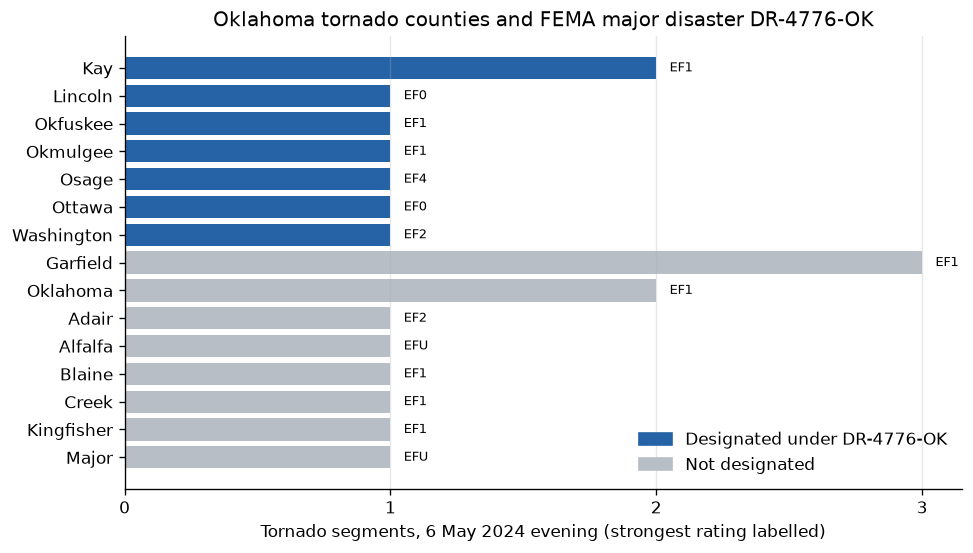

In [7]:
ordered = joined.sort_values(["designated", "tornadoes", "CZ_NAME"], ascending=[True, True, False])
colors = ordered["designated"].map({True: "#2563a6", False: "#b8bec6"})
fig, ax = plt.subplots(layout="constrained")
ax.barh(ordered["CZ_NAME"].str.title(), ordered["tornadoes"], color=colors)
for row, (count, rating) in enumerate(zip(ordered["tornadoes"], ordered["strongest"], strict=True)):
    ax.text(count + 0.05, row, rating, va="center", fontsize=8)
ax.set_xlabel("Tornado segments, 6 May 2024 evening (strongest rating labelled)")
ax.set_title("Oklahoma tornado counties and FEMA major disaster DR-4776-OK")
ax.grid(axis="y", visible=False)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.legend(
    handles=[
        Patch(color="#2563a6", label="Designated under DR-4776-OK"),
        Patch(color="#b8bec6", label="Not designated"),
    ],
    loc="lower right",
    frameon=False,
)
plt.show()

In [8]:
designated = sorted(joined.loc[joined["designated"], "CZ_NAME"].str.title())
not_designated = sorted(joined.loc[~joined["designated"], "CZ_NAME"].str.title())
ef4 = joined.loc[joined["strongest"] == "EF4", "CZ_NAME"].str.title().tolist()
print(
    f"{len(designated)} of {len(joined)} tornado counties were designated: {', '.join(designated)}"
)
print(f"Not designated: {', '.join(not_designated)}")
print(f"The evening's EF4 county: {', '.join(ef4)}")

7 of 15 tornado counties were designated: Kay, Lincoln, Okfuskee, Okmulgee, Osage, Ottawa, Washington
Not designated: Adair, Alfalfa, Blaine, Creek, Garfield, Kingfisher, Major, Oklahoma
The evening's EF4 county: Osage


Osage County, where the evening's one EF4 struck, is designated. Oklahoma
County, where the EF1 that the
[severe-weather case study](https://usdata.dev/studies/severe-weather-case-study/)
follows touched down, is not.

That is a statement about designation, not about damage. DR-4776 covers
incidents from 25 April to 9 May, so a county can be designated for a storm on
another day, and a tornado that did little harm earns no declaration. The
declaration was made on 30 April, before this outbreak; the window selects by
the incident period, which is why asking about 6 May finds it. Query details
are in the
[disaster declarations guide](https://docs.usdata.dev/providers/fema-disaster-declarations/).

## Pin and cite

`verify` checks the cached bytes against the lockfile. FEMA revises rows as
incidents close and programs are added, and NCEI republishes the Storm Events
file under a new name when it revises a year, so a later pull can report
drift; `usdata pull dataset.yaml --update <dataset>` accepts the revised
bytes. Keep the manifest, lockfile, and cached bytes together; the citations
below are what a methods section needs, and `usdata cite dataset.yaml` prints
the same.

In [9]:
assert verify(manifest) == []
for citation in cite_lockfile(manifest):
    print(citation.as_text())

fema:disaster-declarations
  Federal Emergency Management Agency (FEMA), OpenFEMA Dataset: Disaster Declarations Summaries - v2. Retrieved from https://www.fema.gov/api/open/v2/DisasterDeclarationsSummaries on [date, time]. This product uses the Federal Emergency Management Agency's OpenFEMA API, but is not endorsed by FEMA. The Federal Government or FEMA cannot vouch for the data or analyses derived from these data after the data have been retrieved from the Agency's website(s).
  homepage: https://www.fema.gov/openfema-data-page/disaster-declarations-summaries-v2
  license: US Government Work (public domain)
  terms: https://www.fema.gov/about/openfema/terms-conditions
  retrieved: 2026-09-24; 1 checksummed asset (10,308 bytes) pinned by usdata 0.26.0
  sources: declarations
noaa:storm-events
  NOAA National Centers for Environmental Information, Storm Events Database, accessed via usdata
  homepage: https://www.ncei.noaa.gov/access/storm-events-database/
  license: US Government Wor

## What was awkward

- The join silently matched only the counties whose code has three digits.
  Both sources keep their county code as text, which is right, but Storm
  Events writes `1` and `19` where FEMA writes `001` and `019`. Nothing
  fails; small counties simply drop out of the join. `str.zfill(3)` fixes it,
  and the reader does not do it for you, because it leaves a source's values
  as delivered.
- OpenFEMA answers a filter it cannot match with a well-formed empty result.
  A full timestamp in a filter is compared against its own percent-encoded
  text, so `ge '2024-05-01T00:00:00.000Z'` is never true; only the filter
  echoed back in the response metadata, still reading `T00%3A00%3A00`, gives
  it away. The adapter sends plain dates, but a hand-written probe hits this.
- Treating a missing `incidentEndDate` as "still open" tripled the Oklahoma
  result with fire declarations from 2005 that nobody ever closed. They are
  excluded by default, so a disaster genuinely under way needs
  `include_open: true` and brings the stale rows with it. There is no good
  default here, only a documented one.
- The program columns arrive as `0` and `1`, and the dates as midnight UTC
  timestamps in text although they are calendar dates. Neither is converted.
- One evening's tornado reports cost the whole year's Storm Events file, about
  13 MB compressed.